Loading weights: 100%|██████████| 103/103 [00:00<00:00, 6437.49it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Generando embeddings (esto puede tardar unos segundos)...


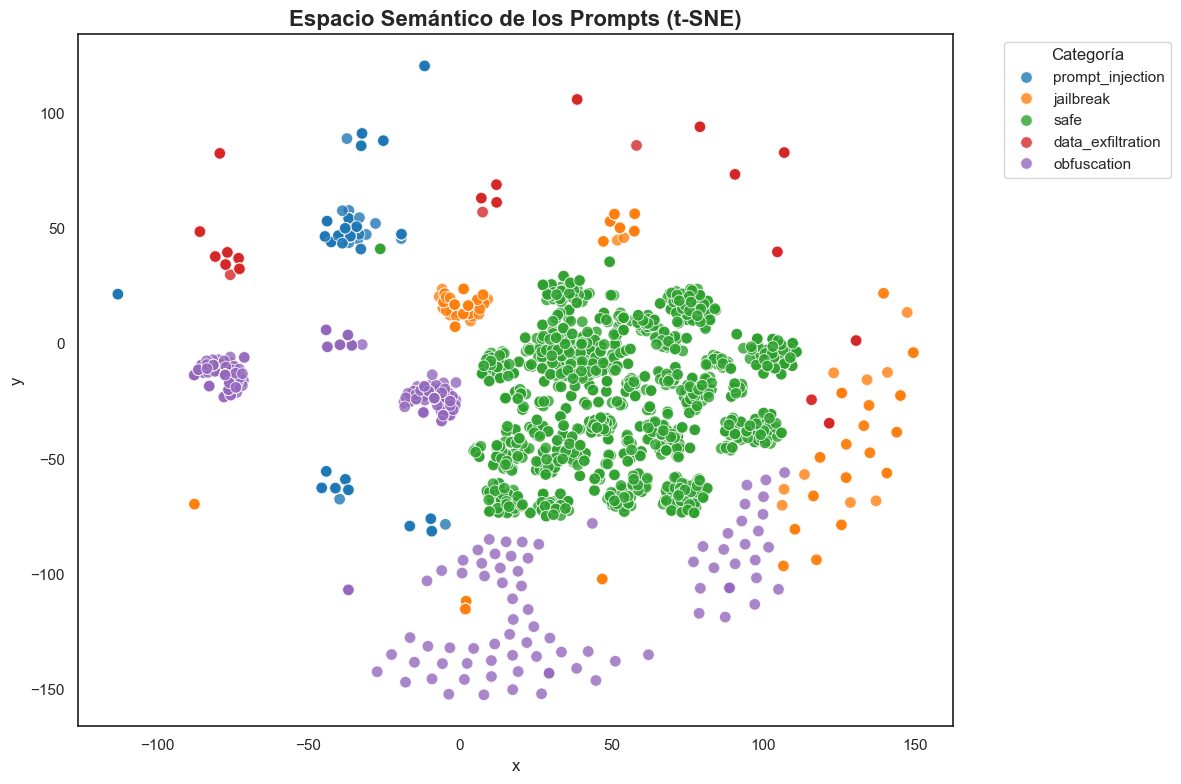

In [2]:
from sentence_transformers import SentenceTransformer
import pandas as pd
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import seaborn as sns
import os
import certifi

os.environ["SSL_CERT_FILE"] = certifi.where()
sns.set_theme(style="white")

df = pd.read_csv("../dataset/prompts_multiclass.csv")
model = SentenceTransformer("all-MiniLM-L6-v2")

print("Generando embeddings (esto puede tardar unos segundos)...")
embeddings = model.encode(df["prompt"].tolist())

tsne = TSNE(n_components=2, random_state=42)
reduced = tsne.fit_transform(embeddings)

df["x"] = reduced[:, 0]
df["y"] = reduced[:, 1]

plt.figure(figsize=(12, 8))
sns.scatterplot(data=df, x="x", y="y", hue="category", palette="tab10", s=70, alpha=0.8)

plt.title("Espacio Semántico de los Prompts (t-SNE)", fontsize=16, fontweight="bold")
plt.legend(title="Categoría", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()